In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')


# fetch dataset 
mushroom = fetch_ucirepo(id=73) 
  
# data (as pandas dataframes) 
X = mushroom.data.features 
y = mushroom.data.targets 
  
df = pd.concat([X, y], axis = 1)

In [2]:
df.isnull().sum()

cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
poisonous                      0
dtype: int64

In [3]:
df.describe()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,6,4,10,2,9,2,2,2,12,2,...,9,9,1,4,3,5,9,6,7,2
top,x,y,n,f,n,f,c,b,b,t,...,w,w,p,w,o,p,w,v,d,e
freq,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,...,4464,4384,8124,7924,7488,3968,2388,4040,3148,4208


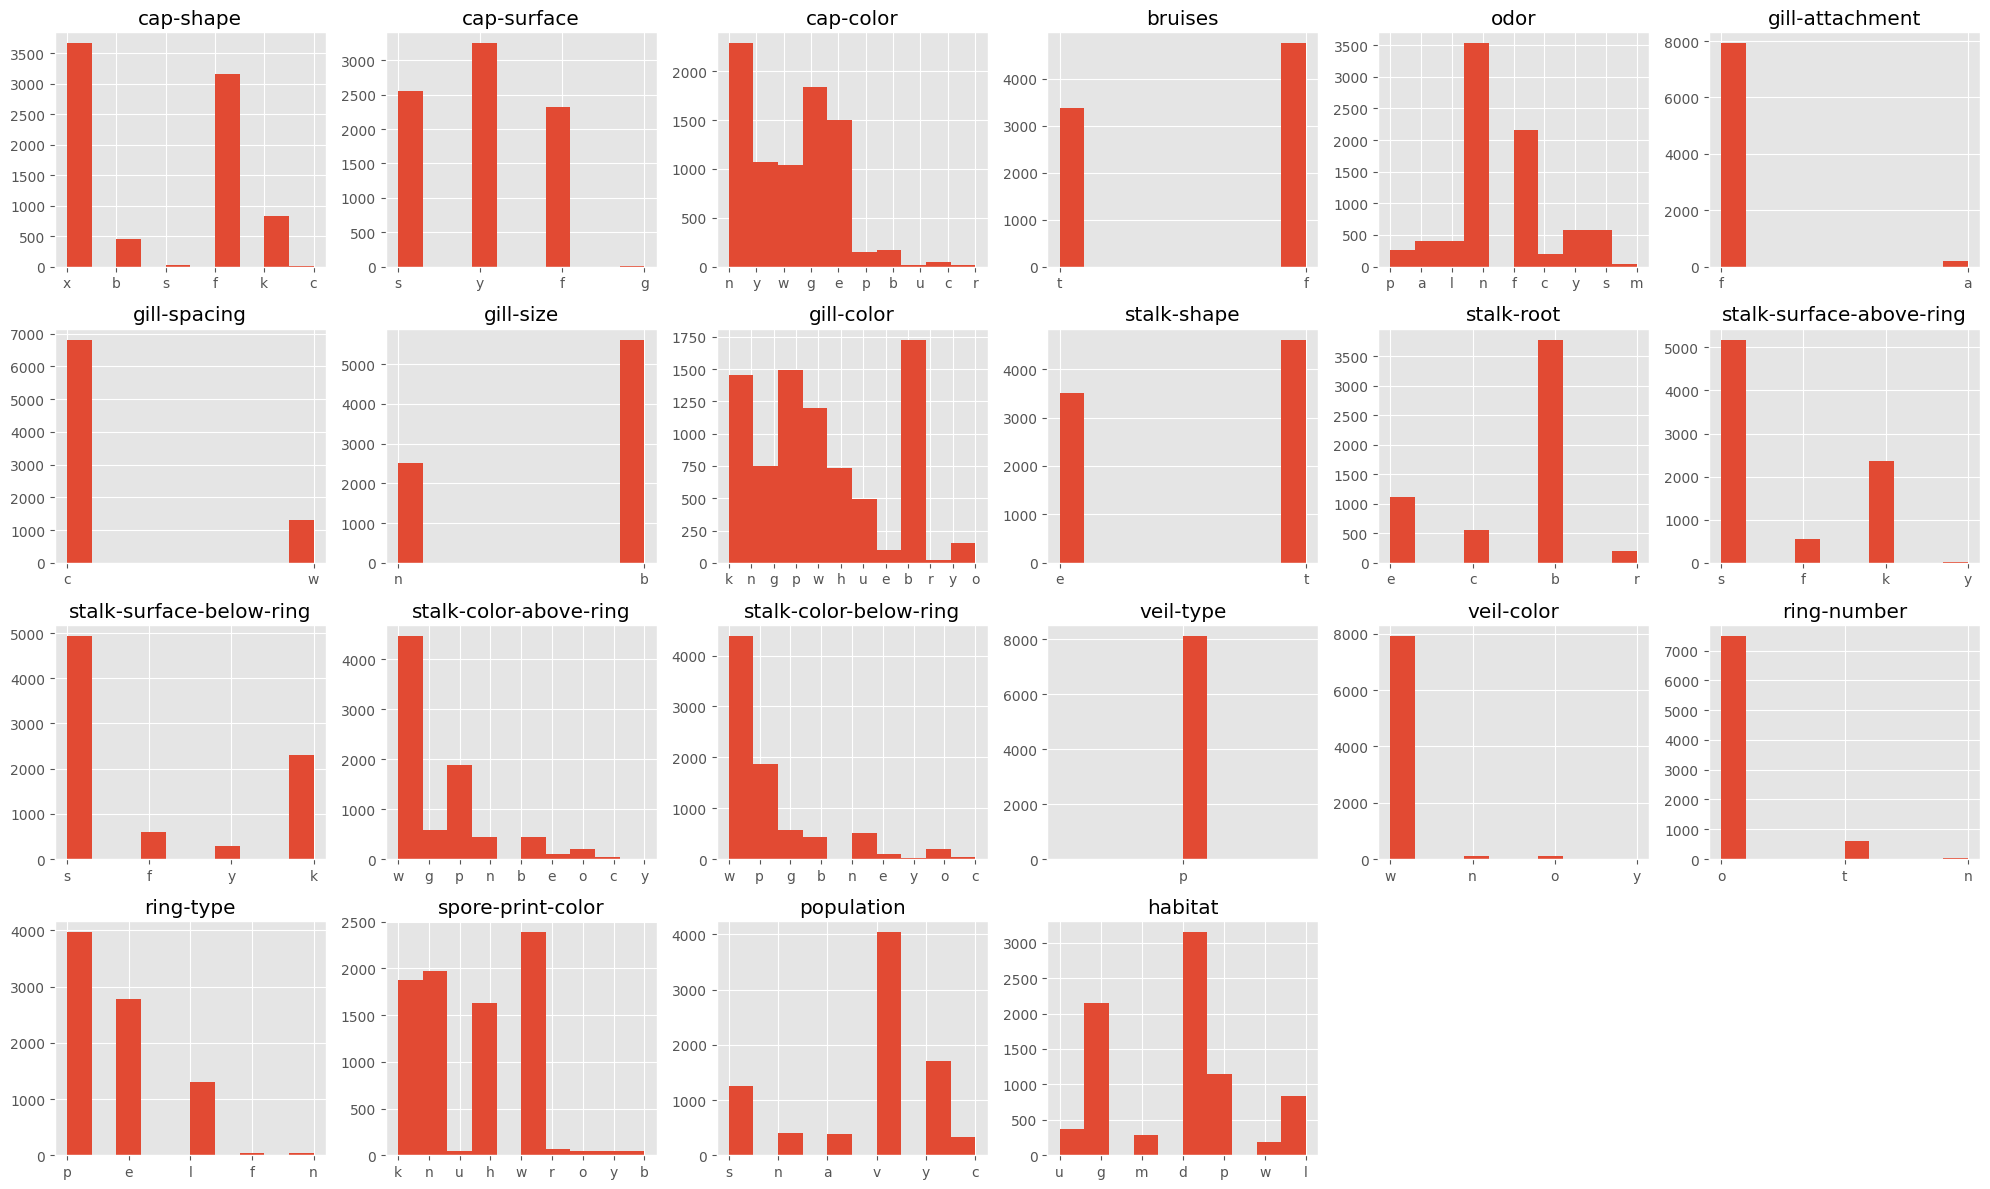

In [4]:
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    X[col].hist(ax=axes[i])
    axes[i].set_title(col)

for ax in axes[len(X.columns):]:
    ax.set_visible(False)
    
plt.tight_layout()
plt.show()

In [9]:
X = X.drop(columns=['veil-type'])

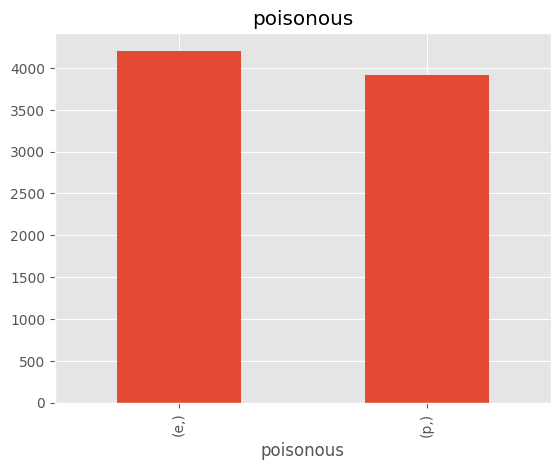

In [8]:
y.value_counts().plot(kind = 'bar')
plt.title('poisonous')
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

oe = OrdinalEncoder()
le = LabelEncoder()


X = pd.DataFrame(oe.fit_transform(X), columns= X.columns)
y = pd.Series(le.fit_transform(y.values.ravel()), name = 'poisonous')


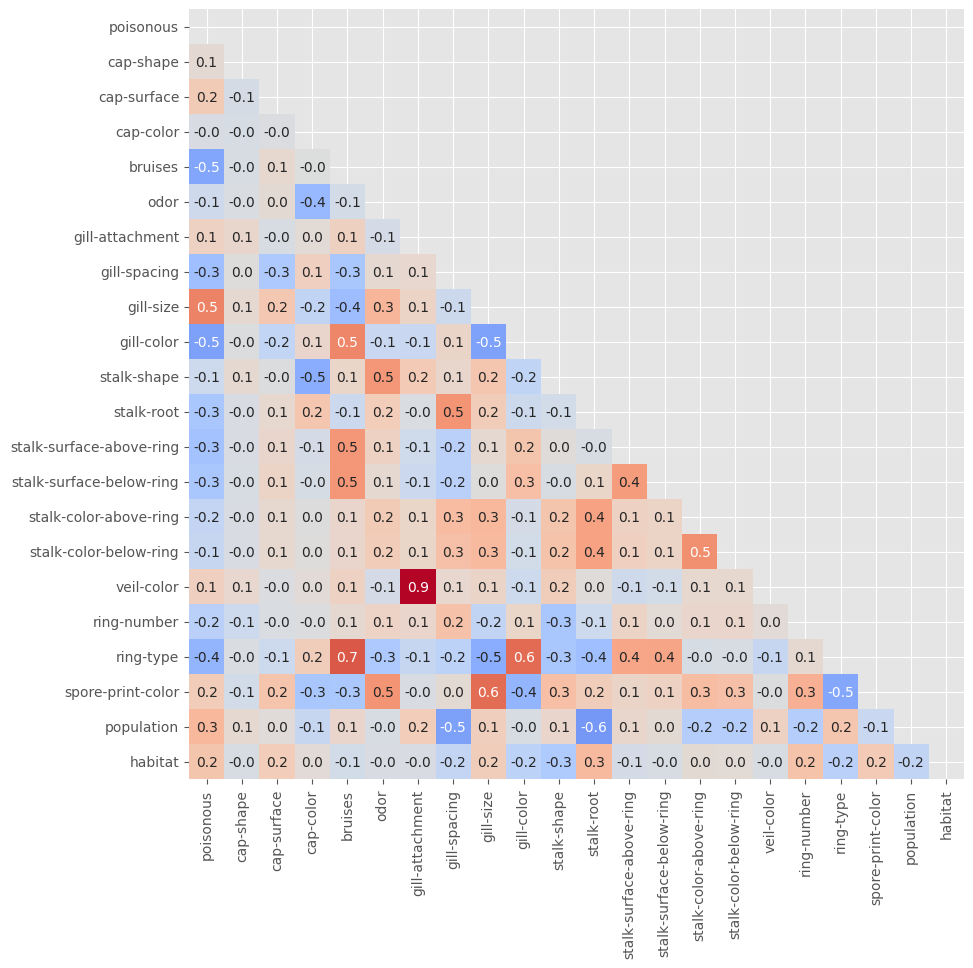

In [16]:
df_corr = pd.concat([y, X], axis = 1)
matrix = df_corr.corr()

mask = np.triu(np.ones_like(matrix, dtype = bool))

plt.figure(figsize=( 10, 10))
sns.heatmap(matrix, mask = mask, cmap = 'coolwarm', fmt = '.1f', annot = True,
            center = 0, cbar = False)

plt.show()


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size= 0.7, random_state= 8, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size= 0.5, random_state= 8, stratify=y_temp)



In [22]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state = 8,
    n_estimators = 200
)

forest = RandomForestClassifier()

xgb.fit(X_train, y_train)
forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


XGB:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       631
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219

Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       631
           1       1.00      1.00      1.00       588

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



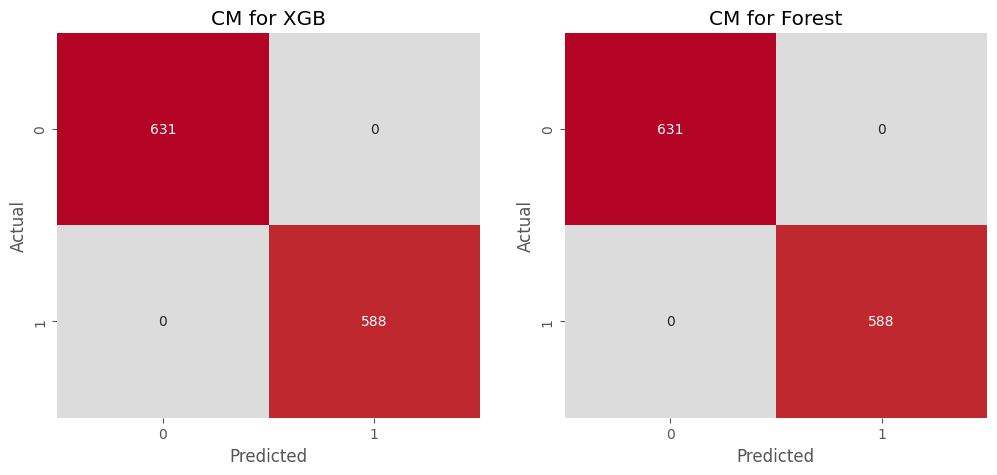

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

xgb_y = xgb.predict(X_test)
forest_y =forest.predict(X_test)

print("XGB:")
print(classification_report(y_true = y_test, y_pred= xgb_y))

print("=" * 20)
print("Forest:")
print(classification_report(y_true = y_test, y_pred= forest_y))



cm_xgb = confusion_matrix(y_true = y_test, y_pred= xgb_y)
cm_forest = confusion_matrix(y_true = y_test, y_pred= forest_y)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_xgb, annot = True, cmap = 'coolwarm',
            fmt = 'd', cbar = False, center = 0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CM for XGB")

plt.subplot(1, 2, 2)
sns.heatmap(cm_forest, annot = True, cmap = 'coolwarm',
            fmt = 'd', cbar = False, center = 0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CM for Forest")

plt.show()


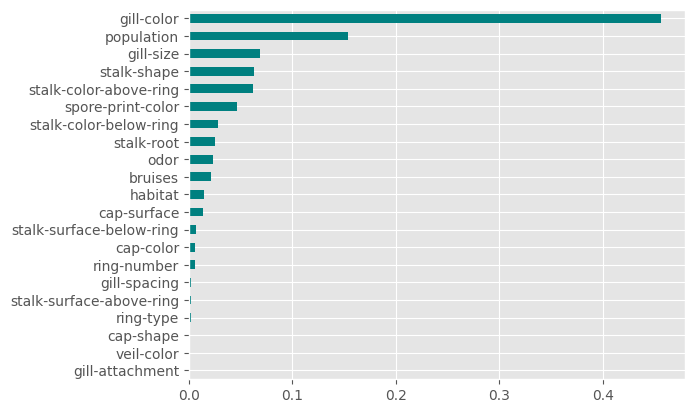

In [28]:
feat_imp = pd.Series(xgb.feature_importances_, index = X.columns).sort_values()

feat_imp.plot(kind= 'barh', color = 'teal')
plt.show()